In [1]:
# For processing the timeseries
import pandas as pd, os, datetime
import geopandas as gpd
import numpy as np
import xarray as xr

# For plotting
import matplotlib.pyplot as plt
import matplotlib.colors as colors


import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import mapping
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Point

In [2]:
nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'
savepath = '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/load_shed_2019'

In [3]:
sdate, edate = '2019-01-05','2019-02-24'

In [4]:
gen_details = pd.read_csv(f"{nmap_path}/gen_details.csv")

In [5]:
nmap = pd.read_csv(f"{nmap_path}/nmap.csv")

In [6]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv")
hw_tseries = hw_tseries.drop(['index','points'], axis=1)

In [7]:
def process_group(grp, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Processes a single group of generator data to 1 day frequency.

    Parameters:
        grp (pd.DataFrame): A single group from gen_details (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """
    gen_locs = gen_fpath + '/' + grp['DUID'] + ".csv"
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]
    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'min'}
    dfs = dfs.groupby(['DUID', pd.Grouper(freq='1d')]).agg(agg_func)

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        dfs.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("12h"),
        direction='nearest'
    )

    return merged

In [8]:
groups = gen_details.groupby('region',
                            as_index = False)

df = groups.get_group('VIC1')
del groups

06/01/2019-12/01/2019 BEFORE
13/01/2019-31/01/2019 DURING 
09/02/2019-16/02/2019 AFTER

In [9]:
# This retrieves only the time surrounding the heatwave
df = process_group(df, gen_fpath, hw_tseries, sdate, edate)
df = df.merge(gen_details[['DUID','fuel_source_primary', 'reg_cap_generation_mw']], on='DUID', how='left')

In [10]:
df = df.merge(nmap[['DUID','lat','lon']], on='DUID',how='left')

In [11]:
EHF_ds = xr.open_dataset('/scratch/ng72/ms5578/hw_files/HW_EHF_2018_2019.nc',
                         engine='netcdf4',
                         chunks='auto')
EHF_ds = EHF_ds.sel(time=slice(sdate,edate))

In [12]:
shpfile = gpd.read_file('/g/data/ng72/ms5578/ID_HW_BARRA/data/raw/STE_2021_AUST_SHP_GDA2020/STE_2021_AUST_GDA2020.shp')
shpfile = shpfile.to_crs("EPSG:4326")

In [13]:
def difference_from_first_week(df, date_col='time', value_col='TOTALMWh', group_cols=['DUID']):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['weekday'] = df[date_col].dt.weekday

    def get_first_week(group):
        first_week_start = group[date_col].min().normalize()
        first_week = group[group[date_col] < first_week_start + pd.Timedelta(days=7)]
        return first_week.set_index('weekday')[[value_col]]

    def compute_diff(group):
        group_data = group.drop(columns=group_cols)
        group_data = group_data.copy()
        group_data[value_col] = group[value_col].values
        group_data[date_col] = group[date_col].values
        group_data['weekday'] = group['weekday'].values

        first_week_vals = get_first_week(group_data)
        group_data = group_data.set_index('weekday')
        group_data['first_week_value'] = group_data.index.map(first_week_vals[value_col].to_dict())
        group_data['diff_from_first_week'] = group_data[value_col] - group_data['first_week_value']
        group_data = group_data.reset_index()
        for col in group_cols:
            group_data[col] = group[col].iloc[0]
        return group_data

    result = df.groupby(group_cols, group_keys=False)[df.columns.tolist()].apply(compute_diff)
    return result

# diff = difference_from_first_week(df)

In [14]:
data = EHF_ds['EHF_val'].transpose('lat','lon','time')

In [15]:
df['reg_cap_generation_mw'] = df['reg_cap_generation_mw'].astype('float')
df['cap_norm'] = df['TOTALMWh']/df['reg_cap_generation_mw']

In [16]:
def plot_year_with_shapefile(array, gdf):
    
    masked = np.ma.masked_where(array == 0, array)

    lons = array.lon.values
    lats = array.lat.values
    lon2d, lat2d = np.meshgrid(lons, lats)

    fig, ax = plt.subplots(figsize=(8, 6),
                           subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

    ax.set_extent([140, 150, -39.5, -33.5], crs=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)

    # Plot heatwave data
    mesh = ax.pcolormesh(lon2d,
                         lat2d,
                         masked,
                         cmap='YlOrRd',
                         shading='auto',
                         transform=ccrs.PlateCarree())

    # Plot each geometry safely
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notnull()]
    ax.add_geometries(gdf.geometry.values,
                      crs=ccrs.PlateCarree(),
                      edgecolor='black',
                      facecolor='none',
                      linewidth=0.3)

    time_str = pd.to_datetime(array.time.values).strftime('%Y-%m-%d')
    ax.set_title(f"Heatwave Events on {time_str}")
    

    return fig, ax

In [17]:
# agg_func = {'TOTALMWh':'sum','EHF_flag':'max', 'EHF_val':'max','lat':'first','lon':'first'}
# agg_df = df.groupby(['DUID', 'time']).aggregate(agg_func).reset_index().sort_values(['DUID', 'time'])
# diff = difference_from_first_week(df,group_cols=['DUID'])

In [18]:
# fig, ax = plot_year_with_shapefile(data, shpfile);

# vmin = diff['diff_from_first_week'].quantile(0.05)
# vmax = diff['diff_from_first_week'].quantile(0.95)

# norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# ax.scatter(diff['lon'],
#            diff['lat'],
#            c=diff['diff_from_first_week'],
#            cmap ='coolwarm',
#            norm=norm,
#            s=50,
#            marker="o",
#            edgecolors='black',
#            linewidths=1,
#            alpha=1,
#            transform=ccrs.PlateCarree())


# fig.show()

In [23]:
# ------------------------
# Setup global color norm
# ------------------------
def plot_scatter(df,data,yval,shpfile):
    all_vals = df[yval]
    
    # Use percentiles to limit outlier impact
    vmin = all_vals.quantile(0.05)
    vmax = all_vals.quantile(0.95)
    
    # Use symmetrical scaling around 0
    abs_max = max(abs(vmin), abs(vmax))
    norm = colors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    cmap = 'cool'
    
    # ------------------------
    # Setup static map
    # ------------------------
    fig, ax = plt.subplots(figsize=(10, 8),
                           subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    
    ax.set_extent([140, 150, -39.5, -33.5], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    
    # Clean shapefile and add once
    shpfile = shpfile[~shpfile.geometry.is_empty & shpfile.geometry.notnull()]
    ax.add_geometries(shpfile.geometry.values,
                      crs=ccrs.PlateCarree(),
                      edgecolor='black',
                      facecolor='none',
                      linewidth=0.3)
    
    # Initialize plot objects
    mesh = None
    scatter = None
    
    # ------------------------
    # Loop through each day
    # ------------------------
    df['time'] = pd.to_datetime(df['time'])
    df['date_only'] = pd.to_datetime(df['time']).dt.date
    
    for t_idx in range(len(data.time)):
        array = data.isel(time=t_idx)
        masked = np.ma.masked_where(array == 0, array)
    
        # Get lat/lon meshgrid
        lons = array.lon.values
        lats = array.lat.values
        lon2d, lat2d = np.meshgrid(lons, lats)
    
        # Remove previous plots
        if mesh is not None:
            mesh.remove()
        if scatter is not None:
            scatter.remove()
    
        # Plot new heatmap (masked array)
        mesh = ax.pcolormesh(lon2d,
                             lat2d,
                             masked,
                             cmap='YlOrRd',
                             shading='auto',
                             transform=ccrs.PlateCarree())
    
        # Get matching scatter data for current day
        this_day = pd.to_datetime(array.time.values).date()
        day_df = df[df['date_only'] == this_day]
    
        # Debug print to check what's going on
        print(f"this_day: {this_day}, matching rows: {len(day_df)}")
    
        scatter = ax.scatter(day_df['lon'],
                             day_df['lat'],
                             c=day_df[yval],
                             cmap=cmap,
                             norm=norm,
                             s=50,
                             edgecolors='black',
                             linewidths=1,
                             alpha=1,
                             transform=ccrs.PlateCarree())

        # Remove existing colorbars (optional if re-running in a loop)
        for ax_cb in fig.axes:
            if ax_cb != ax:
                fig.delaxes(ax_cb)
        
        # Colorbar for mesh (heatmap)
        cbar_ax1 = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
        cbar1 = fig.colorbar(mesh, cax=cbar_ax1)
        cbar1.set_label("EHF Heatmap")
        
        # Colorbar for scatter (capacity factor)
        from matplotlib.cm import ScalarMappable
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])  # Dummy array
        
        cbar_ax2 = fig.add_axes([0.87, 0.25, 0.015, 0.5])
        cbar2 = fig.colorbar(sm, cax=cbar_ax2)
        cbar2.set_label(yval)
    
        # Update title
        ax.set_title(f"Excess Heat Factor and generation as capacity factor {this_day.strftime('%Y-%m-%d')}")
        plt.subplots_adjust(left=0.05, right=0.82, top=0.95, bottom=0.05)
        # OPTIONAL: save frame or pause
        fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/load_shed_2019/day_{t_idx}.png", dpi=150)


this_day: 2019-01-05, matching rows: 52
this_day: 2019-01-06, matching rows: 52
this_day: 2019-01-07, matching rows: 52
this_day: 2019-01-08, matching rows: 52
this_day: 2019-01-09, matching rows: 52
this_day: 2019-01-10, matching rows: 52
this_day: 2019-01-11, matching rows: 52
this_day: 2019-01-12, matching rows: 52
this_day: 2019-01-13, matching rows: 52
this_day: 2019-01-14, matching rows: 52
this_day: 2019-01-15, matching rows: 52
this_day: 2019-01-16, matching rows: 52
this_day: 2019-01-17, matching rows: 52
this_day: 2019-01-18, matching rows: 52
this_day: 2019-01-19, matching rows: 52
this_day: 2019-01-20, matching rows: 52
this_day: 2019-01-21, matching rows: 52
this_day: 2019-01-22, matching rows: 52
this_day: 2019-01-23, matching rows: 52
this_day: 2019-01-24, matching rows: 52
this_day: 2019-01-25, matching rows: 52
this_day: 2019-01-26, matching rows: 52
this_day: 2019-01-27, matching rows: 52
this_day: 2019-01-28, matching rows: 52
this_day: 2019-01-29, matching rows: 52


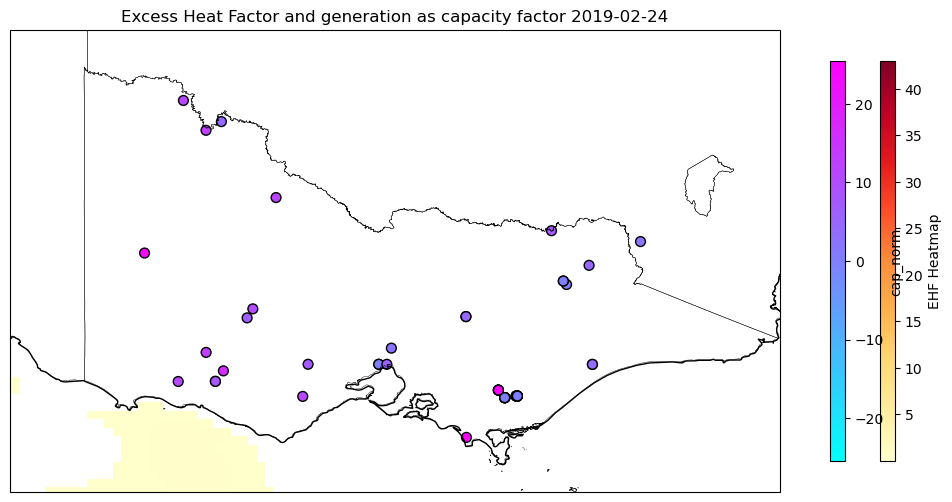

In [24]:
plot_scatter(df,data,'cap_norm',shpfile)
